# CDS 2413 – D2 Machine Learning Model Report

This notebook is rebuilt using the uploaded lab style and follows the D2 project requirements only.

# Preprocessing (5 Points)

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Data/student_habits_performance.csv')
dataset.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## Checking dataset information

In [3]:
print(dataset.shape)
print(dataset.columns)
dataset.info()

(1000, 16)
Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  10

## Data Collection

The dataset is loaded using the pandas library. The dependent variable is `exam_score`.
The independent variables are the remaining student habit and background variables that may affect the exam score.

## Checking missing values

In [4]:
dataset.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

## Checking duplicate rows

In [5]:
dataset.duplicated().sum()

np.int64(0)

## Removing duplicate rows

In [6]:
dataset = dataset.drop_duplicates()
dataset.shape

(1000, 16)

## Taking care of missing data

In [7]:
# Fill missing numeric values with the mean
numeric_columns = dataset.select_dtypes(include=['int64', 'float64']).columns
dataset[numeric_columns] = dataset[numeric_columns].fillna(dataset[numeric_columns].mean())

# Fill missing categorical values with the mode
categorical_columns = dataset.select_dtypes(include=['object']).columns
for col in categorical_columns:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

dataset.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

## Data Cleaning

The dataset was checked for missing values and duplicate records. Duplicate rows were removed.
Missing numerical values were filled using the mean, and missing categorical values were filled using the mode.

## Encoding categorical data

In [8]:
# Remove student_id because it is only an identifier
dataset_model = dataset.drop(columns=['student_id'])

# Encode categorical variables using one-hot encoding
dataset_encoded = pd.get_dummies(dataset_model, drop_first=True, dtype=int)

dataset_encoded.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,0,0,0,0,0,0,1,0,0,1
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,0,0,0,1,0,1,0,0,0,0
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,1,0,0,0,1,1,0,0,1,0
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,0,0,0,0,1,0,1,1,0,1
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,0,0,0,0,0,0,1,1,0,0


## Treating the Categorical Variables

The categorical variables are `gender`, `part_time_job`, `diet_quality`, `parental_education_level`,
`internet_quality`, and `extracurricular_participation`. One-hot encoding was used because the machine
learning models require numerical input.

## Separating independent and dependent variables

In [9]:
X = dataset_encoded.drop(columns=['exam_score'])
y = dataset_encoded['exam_score']

print(X.head())
print(y.head())

   age  study_hours_per_day  social_media_hours  netflix_hours  \
0   23                  0.0                 1.2            1.1   
1   20                  6.9                 2.8            2.3   
2   21                  1.4                 3.1            1.3   
3   23                  1.0                 3.9            1.0   
4   19                  5.0                 4.4            0.5   

   attendance_percentage  sleep_hours  exercise_frequency  \
0                   85.0          8.0                   6   
1                   97.3          4.6                   6   
2                   94.8          8.0                   1   
3                   71.0          9.2                   4   
4                   90.9          4.9                   3   

   mental_health_rating  gender_Male  gender_Other  part_time_job_Yes  \
0                     8            0             0                  0   
1                     8            0             0                  0   
2                

## Detecting and removing outliers using IQR

In [10]:
# Detect outliers from numerical independent variables using the IQR method
outlier_columns = [
    'age',
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating'
]

outlier_indexes = []

for col in outlier_columns:
    Q1 = dataset_encoded[col].quantile(0.25)
    Q3 = dataset_encoded[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataset_encoded[
        (dataset_encoded[col] < lower_bound) |
        (dataset_encoded[col] > upper_bound)
    ]

    outlier_indexes.extend(outliers.index)

outlier_indexes = list(set(outlier_indexes))
dataset_clean = dataset_encoded.drop(index=outlier_indexes)

print("Number of outlier rows removed:", len(outlier_indexes))
print("Shape after removing outliers:", dataset_clean.shape)

Number of outlier rows removed: 21
Shape after removing outliers: (979, 19)


## Splitting the dataset into the Training set and Test set

In [11]:
X = dataset_clean.drop(columns=['exam_score'])
y = dataset_clean['exam_score']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 0
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(783, 18)
(196, 18)
(783,)
(196,)


## Splitting the Dataset

The dataset is split into 80% training and 20% testing. The training set is used to build the model,
and the testing set is used to evaluate the model on unseen data.

## Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[-0.66316241  0.1206378   1.90448103 ...  1.09801357 -0.44412578
  -0.71321141]
 [ 0.63174075  0.94261948  0.70362276 ... -0.91073556 -0.44412578
  -0.71321141]
 [-0.66316241 -0.22185457 -1.95542056 ... -0.91073556 -0.44412578
  -0.71321141]
 ...
 [-1.09479679  1.07961643 -0.32568433 ...  1.09801357 -0.44412578
   1.4021088 ]
 [ 1.06337513  0.39463169 -0.75456229 ... -0.91073556  2.25161441
   1.4021088 ]
 [-0.23152802 -0.70134389 -0.49723551 ...  1.09801357 -0.44412578
  -0.71321141]]
[[ 0.63174075  0.18913627 -1.35499142 ...  1.09801357 -0.44412578
  -0.71321141]
 [-0.23152802  0.87412101 -0.49723551 ...  1.09801357 -0.44412578
   1.4021088 ]
 [-1.52643117 -0.08485762 -0.84033788 ... -0.91073556  2.25161441
   1.4021088 ]
 ...
 [-0.66316241 -0.97533778  0.2747448  ... -0.91073556 -0.44412578
  -0.71321141]
 [-1.52643117  0.53162864  0.78939835 ... -0.91073556 -0.44412578
  -0.71321141]
 [-1.09479679 -0.35885152 -0.5830111  ... -0.91073556  2.25161441
  -0.71321141]]


## Featuring the Dataset

Feature scaling was applied using StandardScaler. Scaling is required for distance-based models such as KNN and SVM.
Regression equation cells below use the original unscaled data so the coefficients can be interpreted with the dataset columns.

# Regression Model (7 Points)

## Building Regression Models

The required regression models are Multiple Linear Regression, Polynomial Regression, Ridge Regression,
Lasso Regression, and Elastic Net Regression. The models are compared using MSE and R2.

## Training the Multiple Linear Regression model on the Training set

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

mlr_mse = mean_squared_error(y_test, y_pred_mlr)
mlr_r2 = r2_score(y_test, y_pred_mlr)

print("Multiple Linear Regression MSE:", mlr_mse)
print("Multiple Linear Regression R2:", mlr_r2)

Multiple Linear Regression MSE: 26.472346723497168
Multiple Linear Regression R2: 0.9046684207341694


## Training the Polynomial Regression model on the Training set

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree = 2, include_bias=False)
X_poly_train = poly_reg.fit_transform(X_train)
X_poly_test = poly_reg.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

y_pred_poly = poly_model.predict(X_poly_test)

poly_mse = mean_squared_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression MSE:", poly_mse)
print("Polynomial Regression R2:", poly_r2)

Polynomial Regression MSE: 28.01112926954014
Polynomial Regression R2: 0.8991269939844674


## Training Ridge Regression model on the Training set

In [15]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression R2:", ridge_r2)

Ridge Regression MSE: 26.47212972147449
Ridge Regression R2: 0.904669202196642


## Training Lasso Regression model on the Training set

In [16]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha = 0.1, max_iter = 10000)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Regression MSE:", lasso_mse)
print("Lasso Regression R2:", lasso_r2)

Lasso Regression MSE: 26.525750222034258
Lasso Regression R2: 0.9044761053377659


## Training Elastic Net Regression model on the Training set

In [17]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha = 0.1, l1_ratio = 0.5, max_iter = 10000)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

elastic_mse = mean_squared_error(y_test, y_pred_elastic)
elastic_r2 = r2_score(y_test, y_pred_elastic)

print("Elastic Net Regression MSE:", elastic_mse)
print("Elastic Net Regression R2:", elastic_r2)

Elastic Net Regression MSE: 26.77633059232799
Elastic Net Regression R2: 0.9035737213261544


## Evaluating the Model Performance

In [18]:
regression_results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Elastic Net Regression'
    ],
    'MSE': [
        mlr_mse,
        poly_mse,
        ridge_mse,
        lasso_mse,
        elastic_mse
    ],
    'R2': [
        mlr_r2,
        poly_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ]
})

regression_results

,Model,MSE,R2
0,Multiple Linear Regression,26.472347,0.904668
1,Polynomial Regression,28.011129,0.899127
2,Ridge Regression,26.472130,0.904669
3,Lasso Regression,26.525750,0.904476
4,Elastic Net Regression,26.776331,0.903574


## Selecting the best fit regression model

In [19]:
best_regression_model_name = regression_results.sort_values(by='R2', ascending=False).iloc[0]['Model']
best_regression_r2 = regression_results.sort_values(by='R2', ascending=False).iloc[0]['R2']

print("Best Regression Model:", best_regression_model_name)
print("Best R2 Score:", best_regression_r2)

Best Regression Model: Ridge Regression
Best R2 Score: 0.904669202196642


## Visualisation: Predicted vs Actual

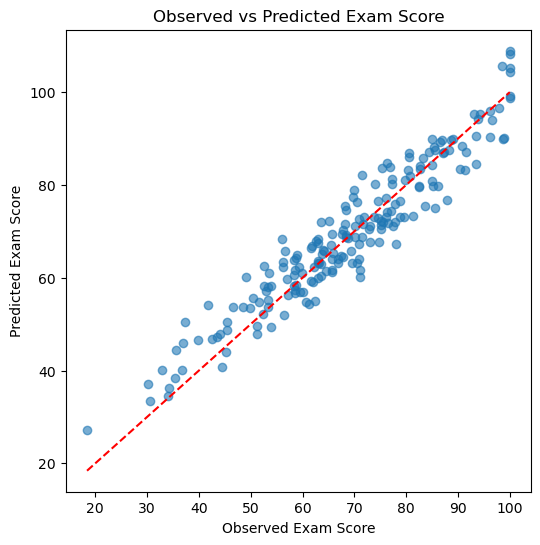

In [20]:
if best_regression_model_name == 'Multiple Linear Regression':
    best_y_pred = y_pred_mlr
elif best_regression_model_name == 'Polynomial Regression':
    best_y_pred = y_pred_poly
elif best_regression_model_name == 'Ridge Regression':
    best_y_pred = y_pred_ridge
elif best_regression_model_name == 'Lasso Regression':
    best_y_pred = y_pred_lasso
else:
    best_y_pred = y_pred_elastic

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Observed vs Predicted Exam Score')
plt.xlabel('Observed Exam Score')
plt.ylabel('Predicted Exam Score')
plt.show()

## Getting the Final Regression Equation

In [21]:
if best_regression_model_name == 'Multiple Linear Regression':
    final_regression_model = mlr
    final_feature_names = X_train.columns
elif best_regression_model_name == 'Polynomial Regression':
    final_regression_model = poly_model
    final_feature_names = poly_reg.get_feature_names_out(X_train.columns)
elif best_regression_model_name == 'Ridge Regression':
    final_regression_model = ridge
    final_feature_names = X_train.columns
elif best_regression_model_name == 'Lasso Regression':
    final_regression_model = lasso
    final_feature_names = X_train.columns
else:
    final_regression_model = elastic
    final_feature_names = X_train.columns

print("Intercept:", final_regression_model.intercept_)
print("Coefficients:")
for feature, coef in zip(final_feature_names, final_regression_model.coef_):
    print(feature, ":", coef)

Intercept: 7.324879678293065
Coefficients:
age : 0.01218592912813743
study_hours_per_day : 9.685250288800827
social_media_hours : -2.704001932764492
netflix_hours : -2.2703909283908144
attendance_percentage : 0.13833203304475805
sleep_hours : 1.9338880356573103
exercise_frequency : 1.5229641400428915
mental_health_rating : 1.920914962120773
gender_Male : 0.2825257133327597
gender_Other : 1.0138744599202556
part_time_job_Yes : 0.2626598421021524
diet_quality_Good : -0.7447715191121075
diet_quality_Poor : -0.47454356972935613
parental_education_level_High School : -0.08962998712432241
parental_education_level_Master : -0.16638805921259028
internet_quality_Good : -0.6413656502606062
internet_quality_Poor : -0.4785713961905198
extracurricular_participation_Yes : 0.014928369696411514


## Deriving the Regression Equation

The regression equation is derived using the intercept and coefficients from the best-fit regression model.

`exam_score = intercept + coefficient1(feature1) + coefficient2(feature2) + ...`

Use the printed intercept and coefficients to substitute the selected records manually.

## Choosing 5 records for manual substitution

In [22]:
manual_records = X_test.head(5).copy()
manual_observed = y_test.head(5).copy()

if best_regression_model_name == 'Polynomial Regression':
    manual_predicted = poly_model.predict(poly_reg.transform(manual_records))
else:
    manual_predicted = final_regression_model.predict(manual_records)

manual_table = manual_records.copy()
manual_table['Observed_exam_score'] = manual_observed.values
manual_table['Predicted_exam_score'] = manual_predicted

manual_table

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes,Observed_exam_score,Predicted_exam_score
282,22,3.8,0.9,2.0,79.9,6.2,1,10,1,0,1,0,0,1,0,1,0,0,79.7,81.011677
469,20,4.8,1.9,1.1,85.1,8.1,1,8,1,0,0,0,0,0,0,1,0,1,96.1,90.405687
800,17,3.4,1.5,1.0,90.8,7.5,4,7,1,0,0,1,0,0,0,0,1,1,86.1,79.812579
485,22,4.1,1.6,0.6,73.1,5.5,5,1,0,0,0,0,0,1,0,1,0,0,77.5,71.167054
913,18,3.8,4.5,1.6,79.3,5.3,3,4,1,0,1,1,0,1,0,1,0,0,53.5,61.088851


**Manual report step:** Use the five selected records above to substitute values into the equation by hand.
Then draw the observed vs predicted scatter plot on paper and scan it into the Word report as requested.

# Classification Model (8 Points)

## Classifying the dataset based on the target variable

In [23]:
# Define the target variable as a categorical value based on exam_score
# Pass = exam_score >= 60
# Fail = exam_score < 60

classification_data = dataset_clean.copy()
classification_data['Category'] = np.where(classification_data['exam_score'] >= 60, 'Pass', 'Fail')

classification_data[['exam_score', 'Category']].head()

,exam_score,Category
0,56.2,Fail
1,100.0,Pass
2,34.3,Fail
3,26.8,Fail
4,66.4,Pass


## Target Variable Categorization

The target variable was converted into a categorical value. Students with `exam_score` greater than or equal to 60
are classified as `Pass`, and students with `exam_score` below 60 are classified as `Fail`.

## No of elements on the target variable

In [24]:
classification_data['Category'].value_counts()

Category
Pass    703
Fail    276
Name: count, dtype: int64

## Splitting the classification dataset into the Training set and Test set

In [25]:
X_classification = classification_data.drop(columns=['exam_score', 'Category'])
y_classification = classification_data['Category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_classification, y_classification, test_size = 0.2, random_state = 0, stratify = y_classification
)

print(X_train_c.shape)
print(X_test_c.shape)
print(y_train_c.shape)
print(y_test_c.shape)

(783, 18)
(196, 18)
(783,)
(196,)


## Feature Scaling for Classification

In [26]:
sc_classification = StandardScaler()
X_train_c_scaled = sc_classification.fit_transform(X_train_c)
X_test_c_scaled = sc_classification.transform(X_test_c)

## Training the Logistic Regression model on the Training set

In [27]:
from sklearn.linear_model import LogisticRegression

classifier_log = LogisticRegression(max_iter = 5000, random_state = 0)
classifier_log.fit(X_train_c_scaled, y_train_c)

y_pred_log = classifier_log.predict(X_test_c_scaled)

## Making the Confusion Matrix for Logistic Regression

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm_log = confusion_matrix(y_test_c, y_pred_log, labels=['Fail', 'Pass'])
print(cm_log)
print("Accuracy:", accuracy_score(y_test_c, y_pred_log))
print("Precision:", precision_score(y_test_c, y_pred_log, pos_label='Pass', zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_log, pos_label='Pass', zero_division=0))
print("F1 Score:", f1_score(y_test_c, y_pred_log, pos_label='Pass', zero_division=0))

[[ 49   6]
 [ 12 129]]
Accuracy: 0.9081632653061225
Precision: 0.9555555555555556
Recall: 0.9148936170212766
F1 Score: 0.9347826086956522


## Training the K-NN model on the Training set

In [29]:
from sklearn.neighbors import KNeighborsClassifier

classifier_knn = KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 2)
classifier_knn.fit(X_train_c_scaled, y_train_c)

y_pred_knn = classifier_knn.predict(X_test_c_scaled)

## Making the Confusion Matrix for K-NN

In [30]:
cm_knn = confusion_matrix(y_test_c, y_pred_knn, labels=['Fail', 'Pass'])
print(cm_knn)
print("Accuracy:", accuracy_score(y_test_c, y_pred_knn))
print("Precision:", precision_score(y_test_c, y_pred_knn, pos_label='Pass', zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_knn, pos_label='Pass', zero_division=0))
print("F1 Score:", f1_score(y_test_c, y_pred_knn, pos_label='Pass', zero_division=0))

[[ 21  34]
 [  6 135]]
Accuracy: 0.7959183673469388
Precision: 0.7988165680473372
Recall: 0.9574468085106383
F1 Score: 0.8709677419354839


## Training the Naive Bayes model on the Training set

In [31]:
from sklearn.naive_bayes import GaussianNB

classifier_nb = GaussianNB()
classifier_nb.fit(X_train_c_scaled, y_train_c)

y_pred_nb = classifier_nb.predict(X_test_c_scaled)

## Making the Confusion Matrix for Naive Bayes

In [32]:
cm_nb = confusion_matrix(y_test_c, y_pred_nb, labels=['Fail', 'Pass'])
print(cm_nb)
print("Accuracy:", accuracy_score(y_test_c, y_pred_nb))
print("Precision:", precision_score(y_test_c, y_pred_nb, pos_label='Pass', zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_nb, pos_label='Pass', zero_division=0))
print("F1 Score:", f1_score(y_test_c, y_pred_nb, pos_label='Pass', zero_division=0))

[[ 42  13]
 [  8 133]]
Accuracy: 0.8928571428571429
Precision: 0.910958904109589
Recall: 0.9432624113475178
F1 Score: 0.926829268292683


## Training the SVM model on the Training set

In [33]:
from sklearn.svm import SVC

classifier_svm = SVC(kernel = 'rbf', random_state = 0)
classifier_svm.fit(X_train_c_scaled, y_train_c)

y_pred_svm = classifier_svm.predict(X_test_c_scaled)

## Making the Confusion Matrix for SVM

In [34]:
cm_svm = confusion_matrix(y_test_c, y_pred_svm, labels=['Fail', 'Pass'])
print(cm_svm)
print("Accuracy:", accuracy_score(y_test_c, y_pred_svm))
print("Precision:", precision_score(y_test_c, y_pred_svm, pos_label='Pass', zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_svm, pos_label='Pass', zero_division=0))
print("F1 Score:", f1_score(y_test_c, y_pred_svm, pos_label='Pass', zero_division=0))

[[ 45  10]
 [  8 133]]
Accuracy: 0.9081632653061225
Precision: 0.9300699300699301
Recall: 0.9432624113475178
F1 Score: 0.9366197183098591


## Training the Decision Tree model on the Training set

In [35]:
from sklearn.tree import DecisionTreeClassifier

classifier_dt = DecisionTreeClassifier(random_state = 0)
classifier_dt.fit(X_train_c, y_train_c)

y_pred_dt = classifier_dt.predict(X_test_c)

## Making the Confusion Matrix for Decision Tree

In [36]:
cm_dt = confusion_matrix(y_test_c, y_pred_dt, labels=['Fail', 'Pass'])
print(cm_dt)
print("Accuracy:", accuracy_score(y_test_c, y_pred_dt))
print("Precision:", precision_score(y_test_c, y_pred_dt, pos_label='Pass', zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_dt, pos_label='Pass', zero_division=0))
print("F1 Score:", f1_score(y_test_c, y_pred_dt, pos_label='Pass', zero_division=0))

[[ 41  14]
 [ 16 125]]
Accuracy: 0.8469387755102041
Precision: 0.8992805755395683
Recall: 0.8865248226950354
F1 Score: 0.8928571428571429


## Training the Random Forest model on the Training set

In [37]:
from sklearn.ensemble import RandomForestClassifier

classifier_rf = RandomForestClassifier(n_estimators = 100, random_state = 0)
classifier_rf.fit(X_train_c, y_train_c)

y_pred_rf = classifier_rf.predict(X_test_c)

## Making the Confusion Matrix for Random Forest

In [38]:
cm_rf = confusion_matrix(y_test_c, y_pred_rf, labels=['Fail', 'Pass'])
print(cm_rf)
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print("Precision:", precision_score(y_test_c, y_pred_rf, pos_label='Pass', zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_rf, pos_label='Pass', zero_division=0))
print("F1 Score:", f1_score(y_test_c, y_pred_rf, pos_label='Pass', zero_division=0))

[[ 43  12]
 [  6 135]]
Accuracy: 0.9081632653061225
Precision: 0.9183673469387755
Recall: 0.9574468085106383
F1 Score: 0.9375


## Comparing Classification Models

In [39]:
classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'SVM',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test_c, y_pred_log),
        accuracy_score(y_test_c, y_pred_knn),
        accuracy_score(y_test_c, y_pred_nb),
        accuracy_score(y_test_c, y_pred_svm),
        accuracy_score(y_test_c, y_pred_dt),
        accuracy_score(y_test_c, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test_c, y_pred_log, pos_label='Pass', zero_division=0),
        precision_score(y_test_c, y_pred_knn, pos_label='Pass', zero_division=0),
        precision_score(y_test_c, y_pred_nb, pos_label='Pass', zero_division=0),
        precision_score(y_test_c, y_pred_svm, pos_label='Pass', zero_division=0),
        precision_score(y_test_c, y_pred_dt, pos_label='Pass', zero_division=0),
        precision_score(y_test_c, y_pred_rf, pos_label='Pass', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test_c, y_pred_log, pos_label='Pass', zero_division=0),
        recall_score(y_test_c, y_pred_knn, pos_label='Pass', zero_division=0),
        recall_score(y_test_c, y_pred_nb, pos_label='Pass', zero_division=0),
        recall_score(y_test_c, y_pred_svm, pos_label='Pass', zero_division=0),
        recall_score(y_test_c, y_pred_dt, pos_label='Pass', zero_division=0),
        recall_score(y_test_c, y_pred_rf, pos_label='Pass', zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test_c, y_pred_log, pos_label='Pass', zero_division=0),
        f1_score(y_test_c, y_pred_knn, pos_label='Pass', zero_division=0),
        f1_score(y_test_c, y_pred_nb, pos_label='Pass', zero_division=0),
        f1_score(y_test_c, y_pred_svm, pos_label='Pass', zero_division=0),
        f1_score(y_test_c, y_pred_dt, pos_label='Pass', zero_division=0),
        f1_score(y_test_c, y_pred_rf, pos_label='Pass', zero_division=0)
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.908163,0.955556,0.914894,0.934783
1,KNN,0.795918,0.798817,0.957447,0.870968
2,Naive Bayes,0.892857,0.910959,0.943262,0.926829
3,SVM,0.908163,0.930070,0.943262,0.936620
4,Decision Tree,0.846939,0.899281,0.886525,0.892857
5,Random Forest,0.908163,0.918367,0.957447,0.937500


## Selecting the best fit classifier

In [40]:
best_classifier_name = classification_results.sort_values(
    by=['F1 Score', 'Accuracy'], ascending=False
).iloc[0]['Model']

print("Best Classifier:", best_classifier_name)

Best Classifier: Random Forest


## Predicting the dependent variable by using best-fit classifier

In [41]:
if best_classifier_name == 'Logistic Regression':
    best_classifier = classifier_log
    best_classifier_predictions = y_pred_log
elif best_classifier_name == 'KNN':
    best_classifier = classifier_knn
    best_classifier_predictions = y_pred_knn
elif best_classifier_name == 'Naive Bayes':
    best_classifier = classifier_nb
    best_classifier_predictions = y_pred_nb
elif best_classifier_name == 'SVM':
    best_classifier = classifier_svm
    best_classifier_predictions = y_pred_svm
elif best_classifier_name == 'Decision Tree':
    best_classifier = classifier_dt
    best_classifier_predictions = y_pred_dt
else:
    best_classifier = classifier_rf
    best_classifier_predictions = y_pred_rf

print(best_classifier_predictions[:20])

['Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Fail'
 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail']


## No of elements in each category based on best-fit classifier

In [42]:
print("Actual number of elements in each category:")
print(y_classification.value_counts())

print("\nPredicted number of elements in each category from the test set:")
print(pd.Series(best_classifier_predictions).value_counts())

Actual number of elements in each category:
Category
Pass    703
Fail    276
Name: count, dtype: int64

Predicted number of elements in each category from the test set:
Pass    147
Fail     49
Name: count, dtype: int64


# Cluster Analysis (5 Points)

## Selecting features for clustering

In [43]:
# Use two numeric fields for visualization like the K-Means and Hierarchical labs
X_cluster = dataset_clean[['study_hours_per_day', 'exam_score']].values

print(X_cluster)

[[  0.   56.2]
 [  6.9 100. ]
 [  1.4  34.3]
 ...
 [  3.   64.4]
 [  5.4  69.7]
 [  4.3  74.9]]


## Feature Scaling for clustering

In [44]:
sc_cluster = StandardScaler()
X_cluster_scaled = sc_cluster.fit_transform(X_cluster)

print(X_cluster_scaled)

[[-2.44746336 -0.7847715 ]
 [ 2.34967561  1.82410838]
 [-1.47413082 -2.08921144]
 ...
 [-0.36175077 -0.29635107]
 [ 1.30681931  0.01933531]
 [ 0.54205803  0.32906534]]


## Using the elbow method to find the optimal number of clusters

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

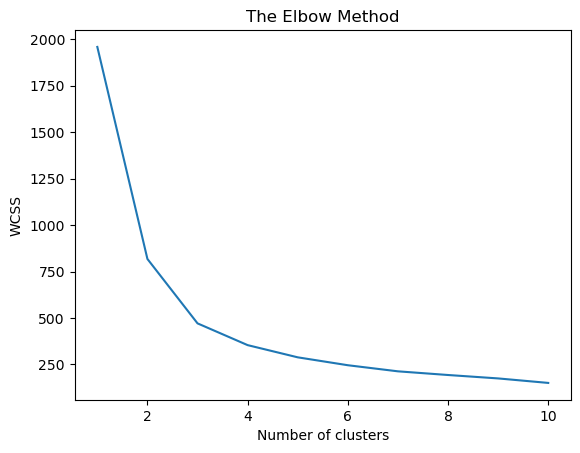

In [45]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42, n_init = 1, max_iter = 100)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means model on the dataset

In [46]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42, n_init = 1, max_iter = 100)
y_kmeans = kmeans.fit_predict(X_cluster_scaled)

print(y_kmeans)

[1 2 1 1 0 2 2 0 0 2 0 0 0 0 0 0 1 0 1 1 0 2 2 1 1 0 0 0 2 0 0 1 1 0 1 0 0
 0 0 2 0 0 0 0 0 0 0 1 1 2 1 1 1 0 0 2 0 0 1 2 1 0 2 0 0 0 0 0 2 2 0 1 0 0
 2 2 1 0 2 0 0 1 1 1 0 1 0 1 0 0 1 0 2 1 2 0 0 0 2 0 0 1 0 1 0 1 1 2 2 0 1
 1 2 0 2 0 0 0 2 0 2 2 1 1 1 2 1 1 0 2 0 2 0 0 0 0 0 0 0 2 0 1 0 0 0 2 0 0
 0 2 2 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 2 2 0 2 0 0 0 1 0 0 0 0 0 2 2 1 1 2
 1 0 1 1 0 2 0 1 0 2 1 0 0 2 0 1 2 0 2 1 0 1 0 2 1 1 2 0 1 2 1 2 2 0 2 1 0
 0 2 2 0 1 2 0 2 0 0 0 1 1 2 1 1 0 2 2 2 1 1 2 1 0 2 0 2 2 0 2 0 0 2 0 0 0
 1 1 1 1 2 1 0 0 0 0 2 1 0 0 0 2 2 2 0 2 0 1 2 1 1 2 2 0 0 2 0 2 1 2 0 2 2
 0 1 0 1 1 2 2 0 1 0 2 0 0 0 1 2 0 0 1 0 2 0 2 0 0 2 1 1 1 2 1 2 0 0 2 2 2
 2 0 0 2 1 1 0 0 0 2 0 2 1 0 1 1 1 0 2 2 1 2 2 0 1 1 2 2 2 0 0 0 1 0 0 1 1
 0 0 1 1 0 2 2 0 1 0 1 0 0 2 0 0 1 1 0 0 2 0 2 0 0 1 1 2 2 0 0 0 1 1 2 1 0
 1 0 0 1 2 1 1 0 2 1 0 0 0 0 0 1 0 1 1 0 2 1 1 0 2 0 0 0 2 0 0 0 1 0 2 2 0
 0 1 2 0 1 0 1 0 2 0 1 2 1 2 2 0 2 0 2 0 1 1 2 1 1 1 2 2 1 0 2 0 0 1 0 0 2
 2 0 0 0 0 0 1 0 2 0 2 2 

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


## Visualising the K-Means clusters

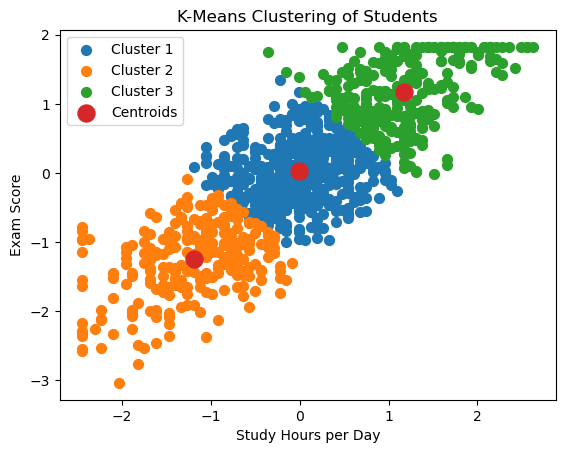

In [47]:
plt.scatter(X_cluster_scaled[y_kmeans == 0, 0], X_cluster_scaled[y_kmeans == 0, 1], s = 50, label = 'Cluster 1')
plt.scatter(X_cluster_scaled[y_kmeans == 1, 0], X_cluster_scaled[y_kmeans == 1, 1], s = 50, label = 'Cluster 2')
plt.scatter(X_cluster_scaled[y_kmeans == 2, 0], X_cluster_scaled[y_kmeans == 2, 1], s = 50, label = 'Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 150, label = 'Centroids')
plt.title('K-Means Clustering of Students')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

## Using the dendrogram to find the optimal number of clusters

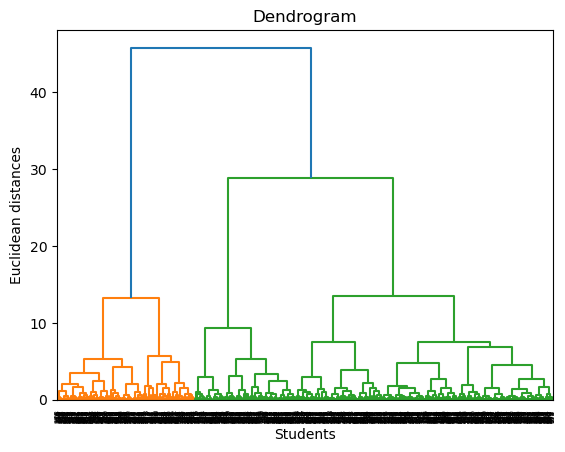

In [48]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(sch.linkage(X_cluster_scaled, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Students')
plt.ylabel('Euclidean distances')
plt.show()

## Training the Hierarchical Clustering model on the dataset

In [49]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters = 3, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X_cluster_scaled)

print(y_hc)

[1 2 1 1 0 2 2 0 0 2 0 0 0 0 0 0 1 0 1 1 0 2 2 1 1 0 0 0 0 0 0 1 1 0 1 0 0
 0 0 2 0 0 0 0 0 0 0 1 1 2 1 1 1 0 0 2 0 0 1 2 1 0 2 0 0 0 0 0 2 2 1 1 0 0
 2 2 1 0 2 0 1 1 1 1 0 1 0 1 0 0 1 0 2 1 2 0 0 0 2 0 0 1 0 1 0 1 1 0 2 0 1
 1 2 0 2 0 0 0 0 0 2 0 0 1 1 2 1 1 0 2 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 0 0
 0 2 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 1 0 2 2 0 2 0 0 0 1 0 0 0 0 0 2 2 1 1 0
 1 0 1 1 0 0 0 1 0 2 1 0 0 2 0 1 2 1 0 1 0 1 0 2 1 1 2 0 1 2 1 2 0 0 2 1 0
 0 2 2 0 1 2 0 2 0 0 0 1 1 0 1 1 0 2 2 2 1 1 2 1 1 2 0 0 2 0 2 0 0 2 0 0 0
 1 1 1 1 2 1 0 0 0 0 0 1 1 0 0 0 2 2 0 2 0 1 2 1 1 0 2 0 0 2 0 2 1 2 0 2 2
 0 1 0 1 1 2 2 0 1 0 2 0 0 0 1 2 0 0 1 1 2 0 2 0 0 0 1 1 1 2 1 2 0 0 2 2 2
 2 0 0 0 1 1 0 0 0 0 0 2 1 0 1 1 1 0 2 0 1 2 2 0 1 1 0 2 2 0 0 0 1 0 0 1 1
 0 0 1 1 0 2 2 0 1 0 1 0 0 2 0 0 1 1 0 0 2 0 0 0 0 1 1 0 2 0 0 0 1 1 0 1 0
 1 0 0 1 2 1 1 0 2 1 0 0 0 0 0 1 0 1 1 0 2 1 1 0 2 0 0 0 2 0 0 0 1 0 2 2 0
 0 1 2 0 1 0 1 1 0 0 1 2 1 2 2 1 2 0 2 0 1 1 2 1 1 1 0 2 1 0 2 0 0 1 0 0 2
 2 0 0 0 0 0 1 0 2 0 2 2 

## Visualising the Hierarchical clusters

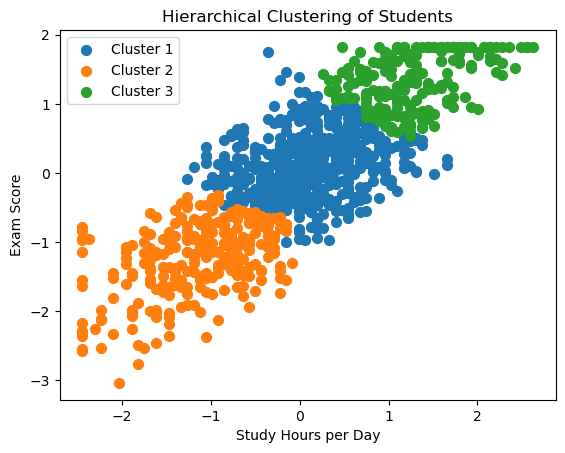

In [54]:
plt.scatter(X_cluster_scaled[y_hc == 0, 0], X_cluster_scaled[y_hc == 0, 1], s = 50, label = 'Cluster 1')
plt.scatter(X_cluster_scaled[y_hc == 1, 0], X_cluster_scaled[y_hc == 1, 1], s = 50, label = 'Cluster 2')
plt.scatter(X_cluster_scaled[y_hc == 2, 0], X_cluster_scaled[y_hc == 2, 1], s = 50, label = 'Cluster 3')
plt.title('Hierarchical Clustering of Students')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

## Cluster Analysis Summary

In [51]:
cluster_summary = pd.DataFrame(X_cluster, columns=['study_hours_per_day', 'exam_score'])
cluster_summary['KMeans_Cluster'] = y_kmeans

cluster_summary.groupby('KMeans_Cluster').mean()

,study_hours_per_day,exam_score
KMeans_Cluster,,
0,3.511765,69.836166
1,1.804669,48.477821
2,5.211787,88.992015


## Strategy Formulation from Clusters

In [52]:
cluster_means = cluster_summary.groupby('KMeans_Cluster').mean()

for cluster in cluster_means.index:
    print("Cluster", cluster)
    print(cluster_means.loc[cluster])

    if cluster_means.loc[cluster, 'exam_score'] < 60:
        print("Strategy: Provide academic support, improve study habits, and monitor progress.")
    elif cluster_means.loc[cluster, 'exam_score'] < 75:
        print("Strategy: Improve consistency through practice tasks and attendance follow-up.")
    else:
        print("Strategy: Maintain strong performance with enrichment and advanced practice.")

    print()

Cluster 0
study_hours_per_day     3.511765
exam_score             69.836166
Name: 0, dtype: float64
Strategy: Improve consistency through practice tasks and attendance follow-up.

Cluster 1
study_hours_per_day     1.804669
exam_score             48.477821
Name: 1, dtype: float64
Strategy: Provide academic support, improve study habits, and monitor progress.

Cluster 2
study_hours_per_day     5.211787
exam_score             88.992015
Name: 2, dtype: float64
Strategy: Maintain strong performance with enrichment and advanced practice.

